In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

## 1. Eksplorasi Data awal

In [4]:
# Load data kita ke sebuah dataframe
data = pd.read_csv('credit_scoring.csv')

In [5]:
# tampilkan jumlah baris dan data
data.shape

(21525, 12)

In [6]:
# tampilkan 10 baris pertama
data.head(10)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,bachelor's degree,0,married,0,F,employee,0,40620.102,purchase of the house
1,1,-4024.803754,36,secondary education,1,married,0,F,employee,0,17932.802,car purchase
2,0,-5623.422610,33,Secondary Education,1,married,0,M,employee,0,23341.752,purchase of the house
3,3,-4124.747207,32,secondary education,1,married,0,M,employee,0,42820.568,supplementary education
4,0,340266.072047,53,secondary education,1,civil partnership,1,F,retiree,0,25378.572,to have a wedding
5,0,-926.185831,27,bachelor's degree,0,civil partnership,1,M,business,0,40922.170,purchase of the house
6,0,-2879.202052,43,bachelor's degree,0,married,0,F,business,0,38484.156,housing transactions
7,0,-152.779569,50,SECONDARY EDUCATION,1,married,0,M,employee,0,21731.829,education
8,2,-6929.865299,35,BACHELOR'S DEGREE,0,civil partnership,1,F,employee,0,15337.093,having a wedding
9,0,-2188.756445,41,secondary education,1,married,0,M,employee,0,23108.150,purchase of the house for my family


## 2. Pengecekan missing value

In [7]:
# lihat informasi dari data kita
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


Terdapat 2 kolom yang memiliki missing values. Kita akan investigasi lebih lanjut

In [8]:
# hitung jumlah missing value di tiap kolom
data.isna().sum()

,0
children,0
days_employed,2174
dob_years,0
education,0
education_id,0
family_status,0
family_status_id,0
gender,0
income_type,0
debt,0


In [9]:
# hitung proporsi missing value di tiap kolom
(data.isna().sum() / data.shape[0]) * 100

,0
children,0.000000
days_employed,10.099884
dob_years,0.000000
education,0.000000
education_id,0.000000
family_status,0.000000
family_status_id,0.000000
gender,0.000000
income_type,0.000000
debt,0.000000


In [10]:
# filter dataframe untuk menampilkan baris yang nilainya null di salah satu kolom
data[data['days_employed'].isna()].head(10)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
12,0,NaN,65,secondary education,1,civil partnership,1,M,retiree,0,NaN,to have a wedding
26,0,NaN,41,secondary education,1,married,0,M,civil servant,0,NaN,education
29,0,NaN,63,secondary education,1,unmarried,4,F,retiree,0,NaN,building a real estate
41,0,NaN,50,secondary education,1,married,0,F,civil servant,0,NaN,second-hand car purchase
55,0,NaN,54,secondary education,1,civil partnership,1,F,retiree,1,NaN,to have a wedding
65,0,NaN,21,secondary education,1,unmarried,4,M,business,0,NaN,transactions with commercial real estate
67,0,NaN,52,bachelor's degree,0,married,0,F,retiree,0,NaN,purchase of the house for my family
72,1,NaN,32,bachelor's degree,0,married,0,M,civil servant,0,NaN,transactions with commercial real estate
82,2,NaN,50,bachelor's degree,0,married,0,F,employee,0,NaN,housing
83,0,NaN,52,secondary education,1,married,0,M,employee,0,NaN,housing


Sepertinya ketika days_employed nilainya null, di kolom total_income juga nilainya akan null. Mari kita pastikan hal ini terlebih dahulu

In [11]:
# filter dataframe untuk menampilkan baris yang nilainya null di kedua kolom sekaligus
data[(data['days_employed'].isnull()) & (data['total_income'].isnull())].shape

(2174, 12)

Jumlah missing value saat kita filter berdasarkan kedua kolom yang memiliki missing value ternyata sama dengan jumlah baris yang memiliki missing value. Artinya saat value di days_employed = Nan, maka value di total_income juga akan Nan.

Jumlah missing data di dataset kita ada sekitar 10 %, sehingga jika kita menghapus semua baris yang memiliki missing value, dapat merubah distribusi dari data kita dan mendistorsi analisa lebih lanjut. Untuk itu kita akan menggunakan metode imputasi data untuk mengatasi missing value. Hal ini akan kita lakukan di bagian imputasi missing value

## Pembersihan Data

### Pengecekan duplikat

In [12]:
# mari kita lihat apakah terdapat duplikat di data kita
print(f"Terdapat {data.duplicated().sum()} baris duplikat di data kita")

Terdapat 54 baris duplikat di data kita


In [13]:
# hapus data duplikat
data = data.drop_duplicates().reset_index(drop=True)

In [14]:
# cek apakah kita sudah berhasil menghapus data duplikat
print(f"Terdapat {data.duplicated().sum()} baris duplikat di data kita")

Terdapat 0 baris duplikat di data kita


### Pengecekan kolom *education*

In [15]:
# mari kita lihat isi dari kolom education
data['education'].unique()

array(["bachelor's degree", 'secondary education', 'Secondary Education',
       'SECONDARY EDUCATION', "BACHELOR'S DEGREE", 'some college',
       'primary education', "Bachelor's Degree", 'SOME COLLEGE',
       'Some College', 'PRIMARY EDUCATION', 'Primary Education',
       'Graduate Degree', 'GRADUATE DEGREE', 'graduate degree'],
      dtype=object)

In [16]:
# mari kita lihat isi dari kolom education
data['education'].value_counts()

,count
education,
secondary education,13705
bachelor's degree,4710
SECONDARY EDUCATION,772
Secondary Education,711
some college,668
BACHELOR'S DEGREE,273
Bachelor's Degree,268
primary education,250
Some College,47


In [17]:
# mari kita samakan value di kolom education menjadi lowercase
data['education'] = data['education'].str.lower()

In [18]:
# lakukan pengecekan kembali ke kolom education
data['education'].value_counts()

,count
education,
secondary education,15188
bachelor's degree,5251
some college,744
primary education,282
graduate degree,6


### Pengecekan kolom *children*

In [19]:
# kita lihat distribusi data di kolom kategorik children
data['children'].value_counts()

,count
children,
0,14107
1,4809
2,2052
3,330
20,76
-1,47
4,41
5,9


In [20]:
print("persentase distribusi data di kolom children :")
data['children'].value_counts(normalize=True) * 100

persentase distribusi data di kolom children :


,proportion
children,
0,65.702576
1,22.397653
2,9.557077
3,1.536957
20,0.353966
-1,0.218900
4,0.190955
5,0.041917


Terdapat beberapa nilai yang aneh di sini. Kita punya beberapa opsi di sini :


1.   Kita bisa hapus baris - baris data yang nilai di kolom childrennya aneh, karena jumlahnya cukup kecil (kurang dari 1%)
2.   Atau kita bisa nilai tersebut dengan nilai lain

Kita akan coba gunakan keduanya pada value yang berbeda


In [21]:
# Kita cek jumlah baris data kita terlebih dahulu
print(f"Jumlah baris data kita sekarang adalah {data.shape[0]}")

Jumlah baris data kita sekarang adalah 21471


In [22]:
# drop / hapus baris yang nilai childrennya negatif
data.drop(data[data['children'] == -1].index, inplace=True)
print(f"Jumlah baris data kita sekarang setelah transformasi adalah {data.shape[0]}")

Jumlah baris data kita sekarang setelah transformasi adalah 21424


In [24]:
# kita dapat berasumsi bahwa terdapat typo saat data children di input
# dimana terdapat ekstra angka 0 di belakang (misal 2 menjadi 20)
# mari kita replace angka tersebut
data['children'] = data['children'].replace(20, 2)

In [25]:
# kita cek lagi data di kolom children
data['children'].value_counts()

,count
children,
0,14107
1,4809
2,2128
3,330
4,41
5,9


data sudah terlihat lebih normal sekarang

### Pengecekan kolom *days_employed*

Selain missing values, terdapat keanehan lain di kolom days_employed dimana terdapat nilai negatif. Hal ini tidak wajar karena jumlah hari seseorang bekerja seharusnya tidak bisa negatif. Mari kita atasi hal ini

In [26]:
# pertama kita cek dulu ada berapa banyak kasus ini
print('Jumlah baris dengan data days_employed negatif :', data[data['days_employed'] < 0].shape[0])
print(f"% baris dengan data days_employed negatif : {data[data['days_employed'] < 0].shape[0]/data.shape[0]:.2%}")

Jumlah baris dengan data days_employed negatif : 15869
% baris dengan data days_employed negatif : 74.07%


In [28]:
# mari kita ubah nilai negatif menjadi nilai positif
data['days_employed'] = data['days_employed'].abs()

In [29]:
# kita cek apakah transformasi kita sudah berhasil
data.head(15)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,8437.673028,42,bachelor's degree,0,married,0,F,employee,0,40620.102,purchase of the house
1,1,4024.803754,36,secondary education,1,married,0,F,employee,0,17932.802,car purchase
2,0,5623.422610,33,secondary education,1,married,0,M,employee,0,23341.752,purchase of the house
3,3,4124.747207,32,secondary education,1,married,0,M,employee,0,42820.568,supplementary education
4,0,340266.072047,53,secondary education,1,civil partnership,1,F,retiree,0,25378.572,to have a wedding
5,0,926.185831,27,bachelor's degree,0,civil partnership,1,M,business,0,40922.170,purchase of the house
6,0,2879.202052,43,bachelor's degree,0,married,0,F,business,0,38484.156,housing transactions
7,0,152.779569,50,secondary education,1,married,0,M,employee,0,21731.829,education
8,2,6929.865299,35,bachelor's degree,0,civil partnership,1,F,employee,0,15337.093,having a wedding
9,0,2188.756445,41,secondary education,1,married,0,M,employee,0,23108.150,purchase of the house for my family


### Pengecekan kolom umur pelanggan (*dob_years*)

In [32]:
# Mari kita urutkan nilai unik di kolom dob_years

data['dob_years'].value_counts().sort_index().head()

,count
dob_years,
0,101
19,14
20,51
21,111
22,183


In [33]:
# terdapat beberapa pelanggan yang umurnya 0. Mari kita hapus saja baris
# data tersebut
data.drop(data[data['dob_years'] == 0].index, inplace=True)

In [34]:
# Kita cek kembali hasil transformasi kita

data['dob_years'].value_counts().sort_index().head()

,count
dob_years,
19,14
20,51
21,111
22,183
23,252


### Pengecekan kolom *gender*


In [35]:
# mari kita lihat kolom gender
data['gender'].value_counts()

,count
gender,
F,14082
M,7240
XNA,1


In [36]:
# mari kita hapus baris data yang nilainya XNA
data.drop(data[data['gender'] == 'XNA'].index, inplace=True)

In [37]:
# kita perikasa hasilnya
data['gender'].value_counts()

,count
gender,
F,14082
M,7240


## Imputasi / Mengisi missing values

In [ ]:
# tapi sebelumnya kita coba cek terlebih dahulu distribusi data tiap kolom

[]

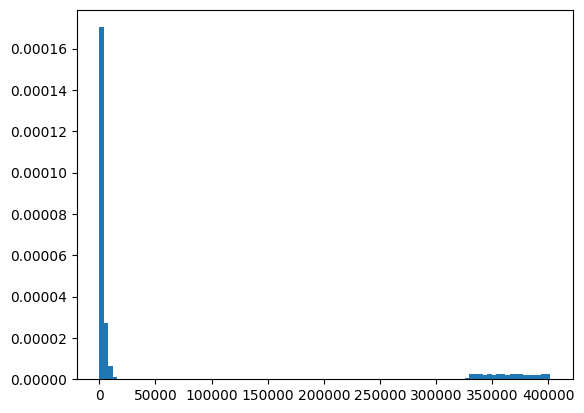

In [38]:
# plot histogram days_employed
plt.hist(data['days_employed'], density=True, bins=100)
plt.plot()

[]

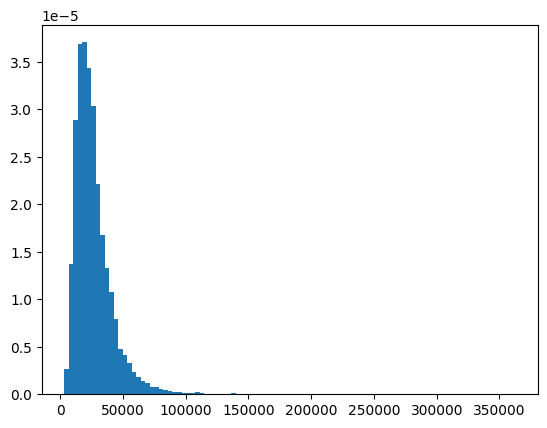

In [39]:
# plot histogram total_income
plt.hist(data['total_income'], density=True, bins=100)
plt.plot()

Terlihat bahwa histogram keduanya memiliki skewness yang positif atau terdapat extreme values/outlier . Artinya kita perlu juga nanti mengatasi outlier di keduanya. Namun untuk saat ini, mari kita isi missing value di kolom *days_employed* dan *total_income* menggunakan median dari kedua kolom tersebut

In [40]:
# simpan nilai median kedua kolom secara terpisah
median_days_employed = data['days_employed'].median()
median_total_income = data['total_income'].median()
print(f"Nilai median untuk kolom days_employed : {median_days_employed}")
print(f"Nilai median untuk kolom total_income : {median_total_income}")

Nilai median untuk kolom days_employed : 2195.688841518035
Nilai median untuk kolom total_income : 23200.877


In [41]:
# kita lakukan imputasi
data['total_income'] = data['total_income'].fillna(median_total_income)
data['days_employed'] = data['days_employed'].fillna(median_days_employed)

In [42]:
# mari kita cek jumlah missing value
data.isna().sum()

,0
children,0
days_employed,0
dob_years,0
education,0
education_id,0
family_status,0
family_status_id,0
gender,0
income_type,0
debt,0


In [43]:
data

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,8437.673028,42,bachelor's degree,0,married,0,F,employee,0,40620.102,purchase of the house
1,1,4024.803754,36,secondary education,1,married,0,F,employee,0,17932.802,car purchase
2,0,5623.422610,33,secondary education,1,married,0,M,employee,0,23341.752,purchase of the house
3,3,4124.747207,32,secondary education,1,married,0,M,employee,0,42820.568,supplementary education
4,0,340266.072047,53,secondary education,1,civil partnership,1,F,retiree,0,25378.572,to have a wedding
...,...,...,...,...,...,...,...,...,...,...,...,...
21466,1,4529.316663,43,secondary education,1,civil partnership,1,F,business,0,35966.698,housing transactions
21467,0,343937.404131,67,secondary education,1,married,0,F,retiree,0,24959.969,purchase of a car
21468,1,2113.346888,38,secondary education,1,civil partnership,1,M,employee,1,14347.610,property
21469,3,3112.481705,38,secondary education,1,married,0,M,employee,1,39054.888,buying my own car
